In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

# House Price Prediction

This notebook rebuilds the complete **House Price Prediction** pipeline using the
Ames Housing dataset (`SalePrice` in **USD**).

We will follow a clean ML lifecycle:

1. Load & inspect data  
2. Split features/target  
3. Build a robust preprocessing pipeline  
4. Train a **baseline Linear Regression** model  
5. Train an improved **Random Forest Regressor** model  
6. Evaluate with MAE / RMSE / R²  
7. Save artifacts for Streamlit UI usage

> **Note:** We apply a `log1p` transformation on `SalePrice` during training to improve
stability, and we convert predictions back using `expm1` for real-world values.


### Dataset Loading

We load the training data and perform a quick sanity check:
- Shape
- Target summary statistics
- Missing value overview


In [2]:
df = pd.read_csv("/kaggle/input/datasets/kavyakatal/housingbig-dataset/train (1).csv")

display(df.head())



,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# Missing values
missing = df.isna().sum().sort_values(ascending=False)
display(missing.head(20))

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
dtype: int64

### Feature Selection

The `Id` column was removed since it represents a unique
identifier and does not contribute to property price prediction.

The target variable `SalePrice` was separated from the
feature dataset before encoding and model preparation.


/tmp/ipykernel_55/4247761891.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(missing.index.astype(str), rotation=75, ha="right")


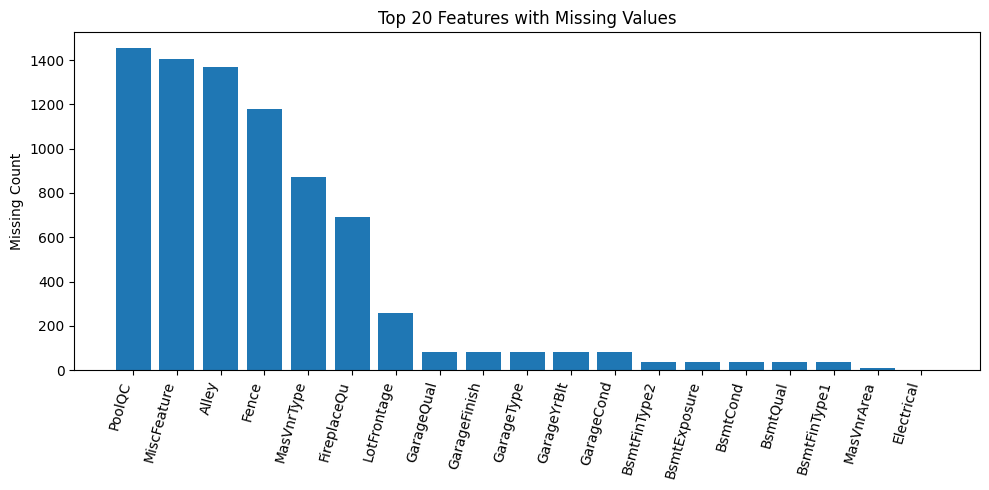

In [16]:
import matplotlib.pyplot as plt

missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0].head(20)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(missing.index.astype(str), missing.values)
ax.set_title("Top 20 Features with Missing Values")
ax.set_ylabel("Missing Count")
ax.set_xticklabels(missing.index.astype(str), rotation=75, ha="right")
plt.tight_layout()
plt.show()

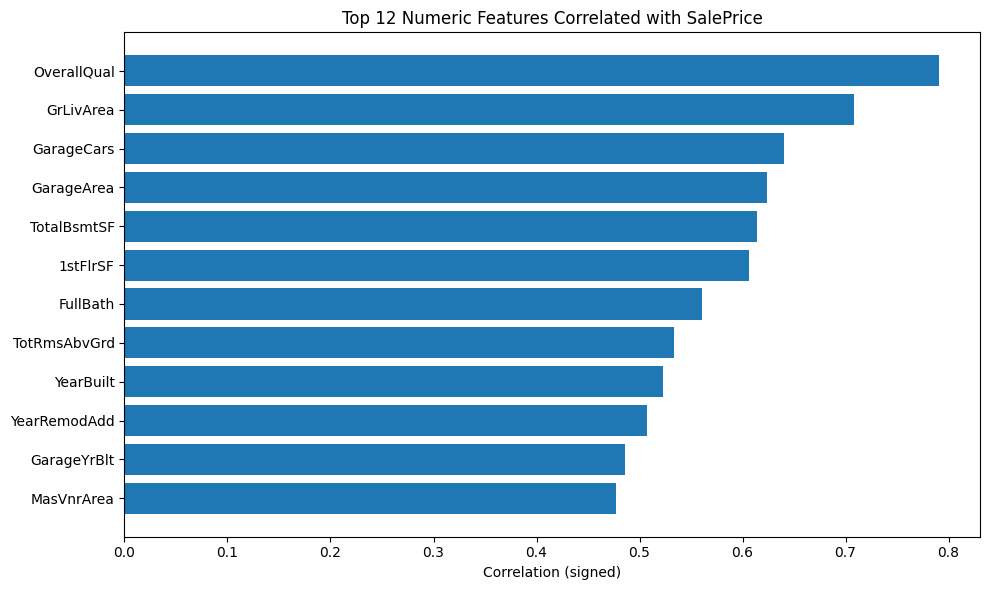

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# numeric-only correlations
num_df = df.select_dtypes(include=[np.number]).copy()

if target_col not in num_df.columns:
    raise ValueError(f"Target '{target_col}' is not numeric in df. Convert it or set correct target column.")

corr = num_df.corr(numeric_only=True)[target_col].drop(labels=[target_col]).dropna()
top_corr = corr.abs().sort_values(ascending=False).head(12)
top_corr_signed = corr.loc[top_corr.index].sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_corr_signed.index.astype(str), top_corr_signed.values)
ax.set_title(f"Top 12 Numeric Features Correlated with {target_col}")
ax.set_xlabel("Correlation (signed)")
plt.tight_layout()
plt.show()

In [4]:
# Separate target and features
y = df["SalePrice"]
X = df.drop(columns=["SalePrice"])

# Drop identifier
if "Id" in X.columns:
    X = X.drop(columns=["Id"])



### Train / Validation Split

We keep a fixed validation set to evaluate models fairly.

A typical split:
- 80% training
- 20% validation


In [5]:
X_train, X_Test, y_train, y_Test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, "| Val:", X_Test.shape)


Train: (1168, 79) | Val: (292, 79)


### Target Variable Transformation

The `SalePrice` variable is usually right-skewed,
which can negatively impact regression model performance.

A logarithmic transformation was applied using `log1p()`
to normalise price distribution and improve model learning
stability.

During prediction we will convert back using:
- `expm1(pred_log)`


In [6]:
# Log-transform the target
y_train_log = np.log1p(y_train)
y_Test_log = np.log1p(y_Test)

### Preprocessing Pipeline

Instead of manual cleaning, we use a `ColumnTransformer`
pipeline that handles:

**Numeric features**
- Median imputation for missing values
- (Optional) Standard scaling for Linear Regression

**Categorical features**
- Most frequent imputation
- One-Hot Encoding with `handle_unknown="ignore"`

This approach ensures that training and Streamlit inference
use the **same transformations**.


In [7]:
# Identify column types
numeric_cols = X_train.select_dtypes(include=["number"]).columns
categorical_cols = X_train.select_dtypes(exclude=["number"]).columns

print("Numeric cols:", len(numeric_cols))
print("Categorical cols:", len(categorical_cols))

# Preprocess for Linear Regression (scaling helps)
numeric_transformer_lr = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_lr = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_lr, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# Preprocess for Random Forest (no scaling required)
numeric_transformer_rf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

preprocess_rf = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_rf, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)


Numeric cols: 36
Categorical cols: 43


### Evaluation Metrics

We evaluate models using:

- **MAE**: average absolute prediction error (lower is better)
- **RMSE**: penalizes large errors more (lower is better)
- **R²**: proportion of variance explained (higher is better)

All metrics are reported in **original USD price units**.


In [8]:
def evaluate_regression(y_true, y_pred, label="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)   # no squared param
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{label}")
    print("-" * len(label))
    print(f"MAE : {mae:,.0f}")
    print(f"RMSE: {rmse:,.0f}")
    print(f"R²  : {r2:.4f}")

    return {"MAE": mae, "RMSE": rmse, "R2": r2}


### Baseline Model — Linear Regression

Linear Regression is used as a baseline regression model
to understand relationships between housing features and
property prices.

We train on `log1p(SalePrice)` and convert predictions back
to USD using `expm1()`.


In [9]:
lr_model = Pipeline(steps=[
    ("preprocess", preprocess_lr),
    ("regressor", LinearRegression())
])

lr_model.fit(X_train, y_train_log)

# Predict (log space) -> convert back to USD
lr_pred_log = lr_model.predict(X_Test)
lr_pred_usd = np.expm1(lr_pred_log)

lr_metrics = evaluate_regression(y_Test, lr_pred_usd, "Linear Regression (log target)")



Linear Regression (log target)
------------------------------
MAE : 14,899
RMSE: 22,740
R²  : 0.9326


### Improved Model — Random Forest Regressor

Housing price relationships are often **non-linear**.
Random Forest handles:

- Non-linear interactions
- Feature interactions without manual engineering
- Robust performance with mixed feature types

We again train on `log1p(SalePrice)` for stability and convert
predictions back to USD.


In [10]:
rf_model = Pipeline(steps=[
    ("preprocess", preprocess_rf),
    ("regressor", RandomForestRegressor(
        n_estimators=600,
        random_state=42,
        n_jobs=-1,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1
    ))
])

rf_model.fit(X_train, y_train_log)

rf_pred_log = rf_model.predict(X_Test)
rf_pred_usd = np.expm1(rf_pred_log)

rf_metrics = evaluate_regression(y_Test, rf_pred_usd, "Random Forest (log target)")



Random Forest (log target)
--------------------------
MAE : 17,495
RMSE: 30,153
R²  : 0.8815


### Model Comparison

We compare the baseline and improved model side-by-side.


In [11]:
comparison = pd.DataFrame([lr_metrics, rf_metrics], index=["LinearRegression", "RandomForest"])
display(comparison)


,MAE,RMSE,R2
LinearRegression,14899.182275,22739.659574,0.932585
RandomForest,17494.712469,30152.791766,0.881466


### Feature Importance (Random Forest)

Random Forest provides feature importance scores which help
interpret what factors matter most.

Because we used One-Hot Encoding, categorical features expand
into multiple columns. We extract the final feature names from
the preprocessing pipeline and plot the top contributors.


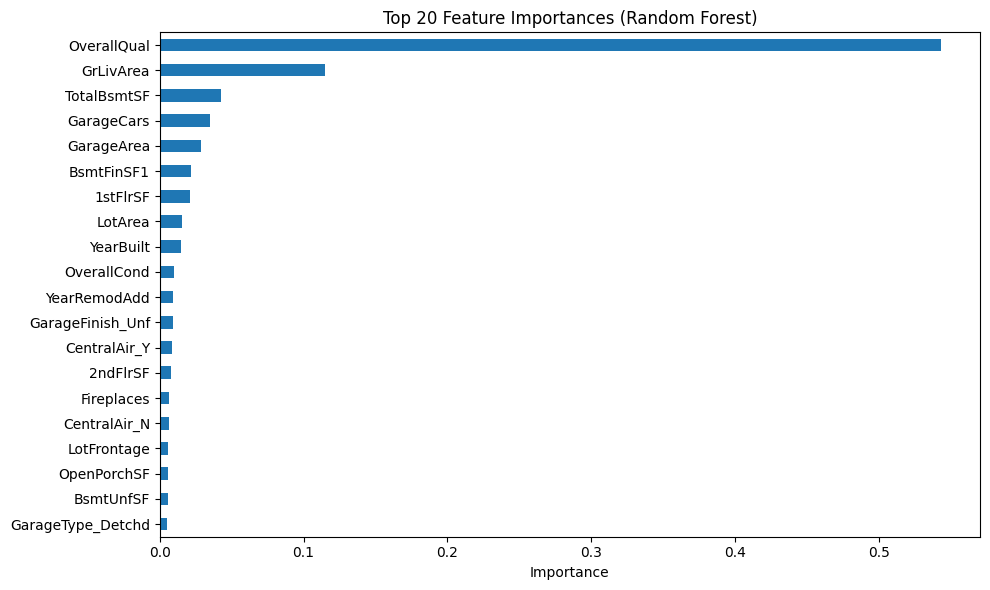

In [12]:
# Extract feature names after preprocessing
ohe = rf_model.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]

cat_feature_names = ohe.get_feature_names_out(categorical_cols)
feature_names = np.r_[numeric_cols, cat_feature_names]

importances = rf_model.named_steps["regressor"].feature_importances_
fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)

top_n = 20
top_fi = fi.head(top_n)

plt.figure(figsize=(10, 6))
top_fi.sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.title(f"Top {top_n} Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()


In [13]:
ARTIFACT_PATH = "/kaggle/working/house_price_lr_pipeline.joblib"

artifacts = {
    "pipeline": lr_model,           # Linear Regression pipeline
    "target_transform": "log1p",    # because we trained on log1p
    "train_columns": list(X_train.columns)
}

joblib.dump(artifacts, ARTIFACT_PATH)

['/kaggle/working/house_price_lr_pipeline.joblib']

### Quick Sanity Test

We run one prediction on a validation row to ensure:

- Pipeline runs end-to-end
- Inverse transform returns realistic price values


In [14]:
sample_row = X_Test.iloc[[0]]
pred_log = rf_model.predict(sample_row)[0]
pred_usd = float(np.expm1(pred_log))

print("Predicted (USD):", round(pred_usd, 2))
print("Actual (USD):   ", float(y_Test.iloc[0]))


Predicted (USD): 139796.94
Actual (USD):    154500.0


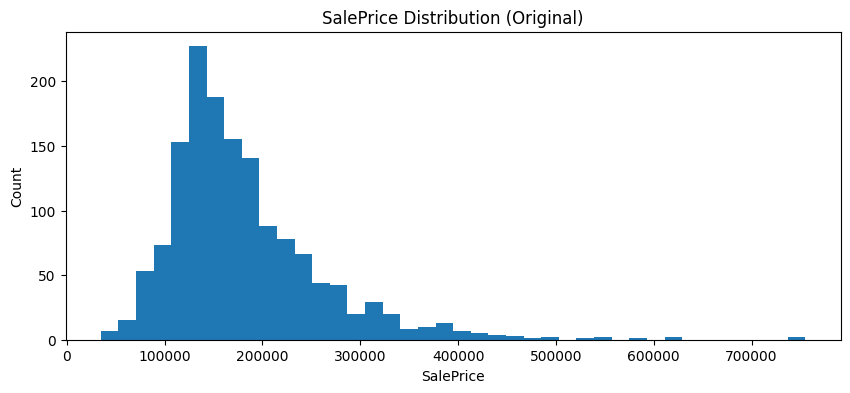

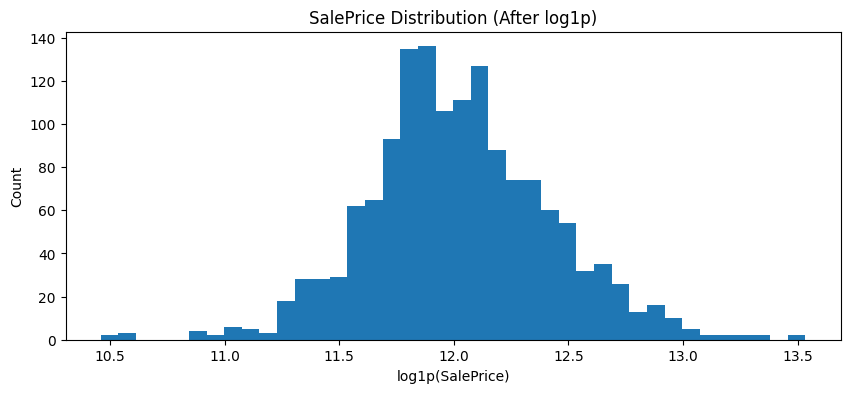

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Detect target column (edit only if your target has a different name) ---
possible_targets = ["SalePrice", "price", "Price", "target", "y"]
target_col = next((c for c in possible_targets if c in df.columns), None)

if target_col is None:
    raise ValueError("Target column not found. Set target_col manually (e.g., target_col='SalePrice').")

y = df[target_col].dropna()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(y, bins=40)
ax.set_title(f"{target_col} Distribution (Original)")
ax.set_xlabel(target_col)
ax.set_ylabel("Count")
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(np.log1p(y), bins=40)
ax.set_title(f"{target_col} Distribution (After log1p)")
ax.set_xlabel(f"log1p({target_col})")
ax.set_ylabel("Count")
plt.show()